# Exploratory Data Analysis and Baseline Model Validation

### Setup and Dependencies

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset

### Data Loading and Preprocessing

In [2]:
data_path = '../data/raw/train_FD001.txt'

df_train = load_cmapss_data(data_path)

print(f"Dataset shape: {df_train.shape}")
display(df_train.head())

Dataset shape: (20631, 27)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


### Streaming Data Simulation

In [3]:
from src.data.data_loader import StreamingCMAPSSDataset
from torch.utils.data import DataLoader

sensor_features = [f's_{i}' for i in range(1, 22)]

train_dataset = StreamingCMAPSSDataset(df_train, sensor_features)

stream_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

X_batch, y_batch = next(iter(stream_loader))
print(f"Feature batch shape (X): {X_batch.shape}")
print(f"Target batch shape (y):  {y_batch.shape}")

Feature batch shape (X): torch.Size([32, 21])
Target batch shape (y):  torch.Size([32, 1])


### Baseline Model Construction

In [5]:
X_train_baseline = df_train[sensor_features]
y_train_baseline = df_train['RUL']

print("Training Random Forest Baseline Model...")
rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_baseline, y_train_baseline)

train_predictions = rf_baseline.predict(X_train_baseline)

rmse = np.sqrt(mean_squared_error(y_train_baseline, train_predictions))
mae = mean_absolute_error(y_train_baseline, train_predictions)

print(f"Baseline Training RMSE: {rmse:.2f} cycles")
print(f"Baseline Training MAE:  {mae:.2f} cycles")

Training Random Forest Baseline Model...
Baseline Training RMSE: 36.37 cycles
Baseline Training MAE:  25.49 cycles


### Degradation Trajectory Visualization - Engine 1

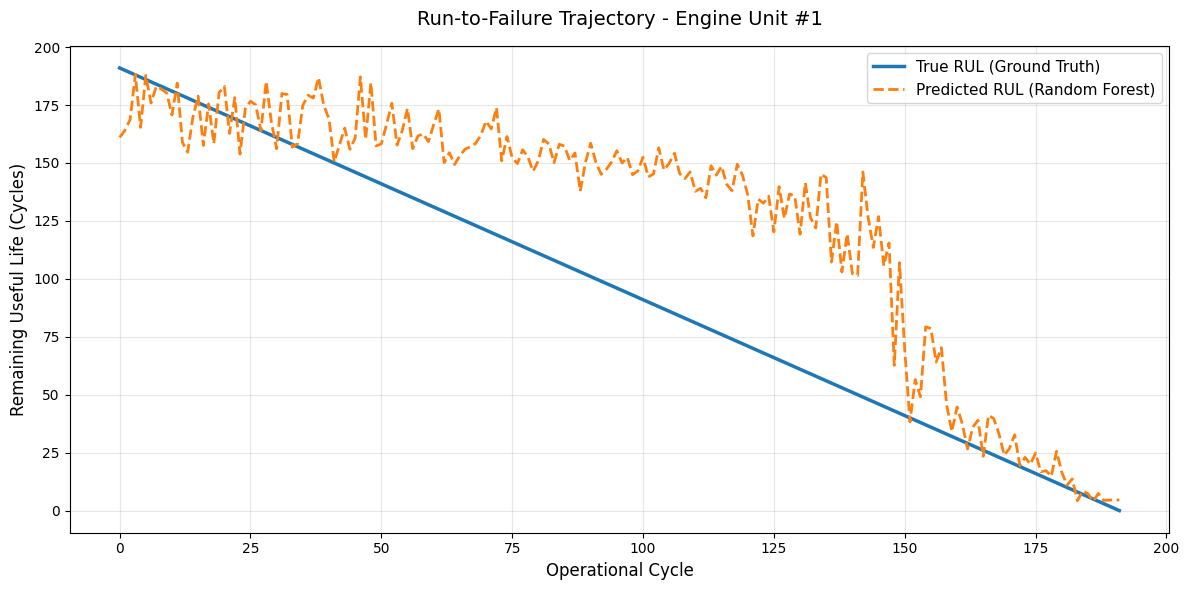

In [6]:
def plot_engine_degradation(df, model, engine_id=1):
    engine_data = df[df['unit_nr'] == engine_id]
    X_engine = engine_data[sensor_features]
    y_true = engine_data['RUL']
    y_pred = model.predict(X_engine)
    
    plt.figure(figsize=(12, 6))
    plt.plot(y_true.values, label="True RUL (Ground Truth)", color='#1f77b4', linewidth=2.5)
    plt.plot(y_pred, label="Predicted RUL (Random Forest)", color='#ff7f0e', linestyle='--', linewidth=2)
    
    plt.title(f"Run-to-Failure Trajectory - Engine Unit #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("Remaining Useful Life (Cycles)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_engine_degradation(df_train, rf_baseline, engine_id=1)